# 11-1. 종일 음이항 NB2 회귀분석

## 음이항 회귀를 사용하는 이유
승차인원은 0 이상의 정수형 빈도 자료이다. Poisson 모형은 조건부 평균과 분산이 같다고 가정하지만, 본 자료에서 분산이 평균보다 크게 나타나 과대산포가 확인되었다. 따라서 과대산포를 허용하는 음이항 NB2 모형을 사용한다.

NB2의 분산은 $Var(Y_i|X_i)=\mu_i+\alpha\mu_i^2$이며, $\alpha>0$이면 분산이 평균보다 크다.

2024년 승차인원은 일반 독립변수가 아니라 offset으로 넣어 2024년 대비 2025년 변화율을 추정한다. 노선 고정효과와 셀 단위 군집 강건 표준오차를 적용한다.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0,str(Path.cwd().parent))
from config import *
setup_notebook()
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial
from IPython.display import display
data=load_model_data(); f=load_cell_route_all_day()
X_FINAL=['walk_20','walk_20_60','ic_access','competing_share','pop_20_50','buildings']; CONT=['ic_access','competing_share','pop_20_50','buildings']
f['셀 ID']=f['셀 ID'].astype(int); f=f.merge(data[['셀 ID']+X_FINAL],on='셀 ID'); f=f[f.y2024>0].reset_index(drop=True)
x=f[X_FINAL].copy()
for c in CONT:
    sd=x[c].std(ddof=0); x[c]=(x[c]-x[c].mean())/(sd if sd else 1)
route=pd.get_dummies(f['노선'],prefix='노선',drop_first=True,dtype=float); X=sm.add_constant(pd.concat([x,route],axis=1),has_constant='add'); offset=np.log(f.y2024)
print('종일 셀×노선:',len(f),'개 | 셀:',f['셀 ID'].nunique(),'개 | 노선:',f['노선'].nunique(),'개')
print('2025 승차인원 평균:',round(f.y2025.mean(),4))
print('2025 승차인원 분산:',round(f.y2025.var(ddof=1),4))
print('단순 자료 분산/평균:',round(f.y2025.var(ddof=1)/f.y2025.mean(),4))

종일 셀×노선: 220 개 | 셀: 132 개 | 노선: 24 개
2025 승차인원 평균: 74.0909
2025 승차인원 분산: 21581.1059
단순 자료 분산/평균: 291.2787


## 1. 과대산포 진단

Pearson dispersion과 deviance/df가 1보다 크게 높으면 Poisson의 평균=분산 가정이 적절하지 않을 가능성이 있다.

In [2]:
pois=sm.GLM(f.y2025,X,family=sm.families.Poisson(),offset=offset).fit()
print('Poisson Pearson dispersion:',round(pois.pearson_chi2/pois.df_resid,4))
print('Poisson deviance/df:',round(pois.deviance/pois.df_resid,4))

Poisson Pearson dispersion: 14.2229
Poisson deviance/df: 12.216


## 2. 음이항 NB2 추정 및 적합도

In [3]:
nb=NegativeBinomial(f.y2025,X,offset=offset,loglike_method='nb2'); start=np.r_[np.asarray(pois.params),0.5]
nb_fit=nb.fit(start_params=start,method='bfgs',maxiter=5000,disp=False,cov_type='cluster',cov_kwds={'groups':pd.factorize(f['셀 ID'])[0],'use_correction':True})
print('converged =',nb_fit.mle_retvals.get('converged')); print('warnflag =',nb_fit.mle_retvals.get('warnflag'))
assert nb_fit.mle_retvals.get('converged') is True and nb_fit.mle_retvals.get('warnflag',0)==0
alpha=float(nb_fit.params.iloc[-1] if hasattr(nb_fit.params,'iloc') else nb_fit.params[-1])
null=NegativeBinomial(f.y2025,np.ones((len(f),1)),offset=offset,loglike_method='nb2'); null_fit=null.fit(start_params=np.array([np.log(f.y2025.sum()/f.y2024.sum()),0.5]),method='bfgs',maxiter=5000,disp=False)
fit_table=pd.DataFrame({'표본 수':[len(f)],'로그우도':[nb_fit.llf],'Null 로그우도':[null_fit.llf],'McFadden pseudo R²':[1-nb_fit.llf/null_fit.llf],'AIC':[nb_fit.aic],'BIC':[nb_fit.bic],'alpha':[alpha]}).round(4)
display(fit_table)
print('NB2 조건부 분산: Var(Y|X)=mu + alpha*mu^2')
print('alpha=',round(alpha,4),'이므로 조건부 분산이 평균보다 큰 과대산포 모형이다.')

converged = True
warnflag = 0


,표본 수,로그우도,Null 로그우도,McFadden pseudo R²,AIC,BIC,alpha
0,220,-938.4253,-989.6589,0.0518,1938.8505,2044.053,0.2193


NB2 조건부 분산: Var(Y|X)=mu + alpha*mu^2
alpha= 0.2193 이므로 조건부 분산이 평균보다 큰 과대산포 모형이다.


## 3. 음이항 NB2 계수·효과·p-value

In [4]:
ci=nb_fit.conf_int().loc[X_FINAL]
out=pd.DataFrame({'변수':[VARIABLE_LABELS.get(v,v) for v in X_FINAL],'계수':[nb_fit.params[v] for v in X_FINAL],'변화율(%)':[(np.exp(nb_fit.params[v])-1)*100 for v in X_FINAL],'95% CI 하한(%)':[(np.exp(ci.loc[v,0])-1)*100 for v in X_FINAL],'95% CI 상한(%)':[(np.exp(ci.loc[v,1])-1)*100 for v in X_FINAL],'p-value':[nb_fit.pvalues[v] for v in X_FINAL]})
display(out.round({'계수':4,'변화율(%)':2,'95% CI 하한(%)':2,'95% CI 상한(%)':2,'p-value':4}))
print('연속형 변수는 1표준편차 증가 기준이다.')

,변수,계수,변화율(%),95% CI 하한(%),95% CI 상한(%),p-value
0,보행 20분 이내,-0.7980,-54.98,-71.47,-28.95,0.0006
1,보행 20~60분,-0.4890,-38.68,-58.48,-9.43,0.0140
2,IC까지 도로거리(km),-0.1716,-15.77,-26.05,-4.05,0.0098
3,GTX 경쟁 목적지 비율(%),-0.1186,-11.18,-22.32,1.56,0.0830
4,2024년 20~50대 인구,-0.0316,-3.12,-13.75,8.83,0.5938
5,2024년 건축물 수,-0.1059,-10.05,-18.54,-0.67,0.0363


연속형 변수는 1표준편차 증가 기준이다.


In [5]:
# 선행연구 Table 3 형식의 최종 결과표
paper_table = pd.DataFrame({
    'Variable': [VARIABLE_LABELS.get(v, v) for v in X_FINAL],
    'coef (p-value)': [f'{nb_fit.params[v]:.4f} ({nb_fit.pvalues[v]:.4f})' for v in X_FINAL],
    '변화율(%)': [(np.exp(nb_fit.params[v]) - 1) * 100 for v in X_FINAL],
})
display(paper_table.round({'변화율(%)': 2}))

model_summary = pd.DataFrame({
    '표본 수': [len(f)],
    'McFadden pseudo R²': [1 - nb_fit.llf / null_fit.llf],
    'AIC': [nb_fit.aic],
    'BIC': [nb_fit.bic],
    'alpha': [alpha],
    'converged': [nb_fit.mle_retvals.get('converged')],
})
display(model_summary.round(4))


,Variable,coef (p-value),변화율(%)
0,보행 20분 이내,-0.7980 (0.0006),-54.98
1,보행 20~60분,-0.4890 (0.0140),-38.68
2,IC까지 도로거리(km),-0.1716 (0.0098),-15.77
3,GTX 경쟁 목적지 비율(%),-0.1186 (0.0830),-11.18
4,2024년 20~50대 인구,-0.0316 (0.5938),-3.12
5,2024년 건축물 수,-0.1059 (0.0363),-10.05


,표본 수,McFadden pseudo R²,AIC,BIC,alpha,converged
0,220,0.0518,1938.8505,2044.053,0.2193,True


In [6]:
# 논문용 음이항 회귀 결과표
ci=nb_fit.conf_int().loc[X_FINAL]
paper_result = pd.DataFrame({
    '변수': [VARIABLE_LABELS.get(v, v) for v in X_FINAL],
    '계수': [nb_fit.params[v] for v in X_FINAL],
    '표준오차': [nb_fit.bse[v] for v in X_FINAL],
    'z값': [nb_fit.params[v] / nb_fit.bse[v] for v in X_FINAL],
    'p-value': [nb_fit.pvalues[v] for v in X_FINAL],
    '95% CI 하한': [ci.loc[v, 0] for v in X_FINAL],
    '95% CI 상한': [ci.loc[v, 1] for v in X_FINAL],
    'IRR': [np.exp(nb_fit.params[v]) for v in X_FINAL],
    '변화율(%)': [(np.exp(nb_fit.params[v]) - 1) * 100 for v in X_FINAL],
})
display(paper_result.round({'계수':4,'표준오차':4,'z값':3,'p-value':4,'95% CI 하한':4,'95% CI 상한':4,'IRR':4,'변화율(%)':2}))
print('주: 연속형 변수는 1표준편차 증가 기준이며, 기준집단은 GTX 보행 60분 초과이다.')


,변수,계수,표준오차,z값,p-value,95% CI 하한,95% CI 상한,IRR,변화율(%)
0,보행 20분 이내,-0.7980,0.2327,-3.429,0.0006,-1.2542,-0.3419,0.4502,-54.98
1,보행 20~60분,-0.4890,0.1989,-2.458,0.0140,-0.8789,-0.0991,0.6132,-38.68
2,IC까지 도로거리(km),-0.1716,0.0665,-2.582,0.0098,-0.3018,-0.0414,0.8423,-15.77
3,GTX 경쟁 목적지 비율(%),-0.1186,0.0684,-1.733,0.0830,-0.2526,0.0155,0.8882,-11.18
4,2024년 20~50대 인구,-0.0316,0.0593,-0.533,0.5938,-0.1479,0.0847,0.9688,-3.12
5,2024년 건축물 수,-0.1059,0.0506,-2.093,0.0363,-0.2050,-0.0067,0.8995,-10.05


주: 연속형 변수는 1표준편차 증가 기준이며, 기준집단은 GTX 보행 60분 초과이다.


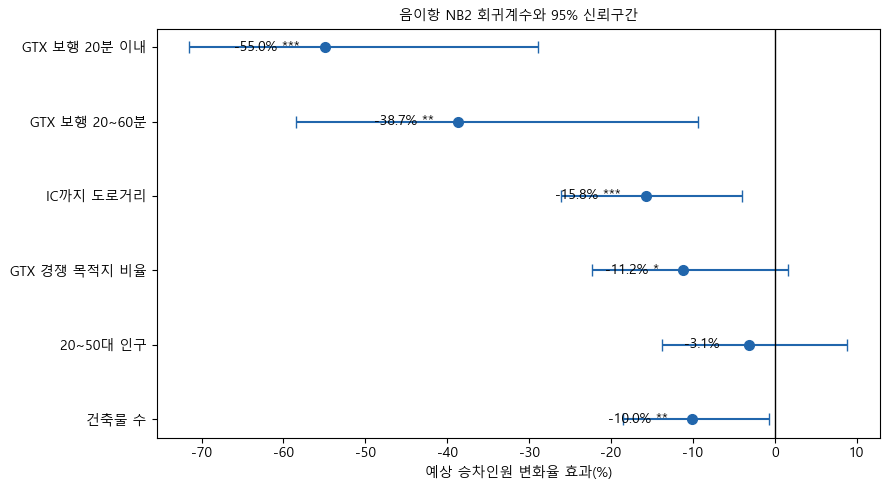

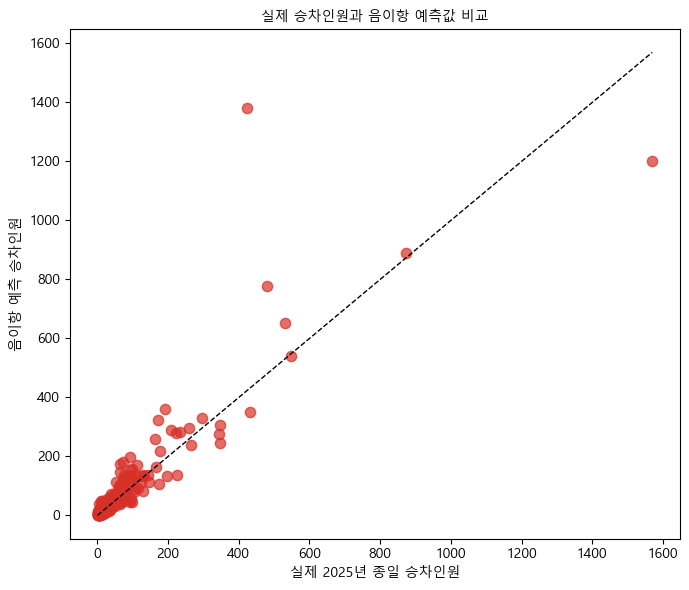

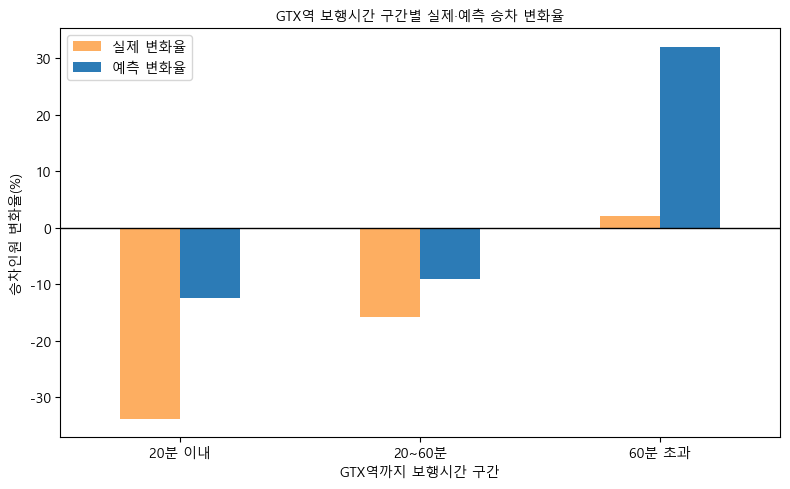

In [7]:
# 음이항 NB2 결과 시각화
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = Path(r"C:\Windows\Fonts\malgun.ttf")
font_prop = fm.FontProperties(fname=str(font_path))
fm.fontManager.addfont(str(font_path))
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

LABELS = {
    'walk_20': 'GTX 보행 20분 이내',
    'walk_20_60': 'GTX 보행 20~60분',
    'ic_access': 'IC까지 도로거리',
    'competing_share': 'GTX 경쟁 목적지 비율',
    'pop_20_50': '20~50대 인구',
    'buildings': '건축물 수',
}

# 1. 변수별 변화율 효과와 95% 신뢰구간
ci = nb_fit.conf_int().loc[X_FINAL]
effect_table = pd.DataFrame({
    '변수': [LABELS.get(v, v) for v in X_FINAL],
    '계수': nb_fit.params.loc[X_FINAL].values,
    '하한': ci[0].values,
    '상한': ci[1].values,
    'p-value': nb_fit.pvalues.loc[X_FINAL].values,
})
effect_table['효과(%)'] = (np.exp(effect_table['계수']) - 1) * 100
effect_table['하한(%)'] = (np.exp(effect_table['하한']) - 1) * 100
effect_table['상한(%)'] = (np.exp(effect_table['상한']) - 1) * 100
effect_table = effect_table.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(effect_table))
x = effect_table['효과(%)'].to_numpy()
xerr = np.vstack([
    x - effect_table['하한(%)'].to_numpy(),
    effect_table['상한(%)'].to_numpy() - x,
])
ax.errorbar(x, y_pos, xerr=xerr, fmt='o', color='#2166ac',
            ecolor='#2166ac', capsize=4, markersize=7)
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(effect_table['변수'].tolist(), fontproperties=font_prop)
ax.set_xlabel('예상 승차인원 변화율 효과(%)', fontproperties=font_prop)
ax.set_title('음이항 NB2 회귀계수와 95% 신뢰구간', fontproperties=font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
for i, row in effect_table.iterrows():
    p = row['p-value']
    mark = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    effect = row['효과(%)']
    ax.text(effect + (3 if effect >= 0 else -3), i,
            f'{effect:.1f}% {mark}', va='center',
            ha='left' if effect >= 0 else 'right',
            fontproperties=font_prop)
plt.tight_layout()
plt.show()

# 2. 실제값과 예측값 산점도
f_plot = f.copy()
f_plot['예측_2025승차인원'] = nb_fit.predict(X, offset=offset)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(f_plot['y2025'], f_plot['예측_2025승차인원'],
           s=55, alpha=0.7, color='#d73027')
max_value = max(f_plot['y2025'].max(), f_plot['예측_2025승차인원'].max())
ax.plot([0, max_value], [0, max_value], '--', color='black', linewidth=1)
ax.set_xlabel('실제 2025년 종일 승차인원', fontproperties=font_prop)
ax.set_ylabel('음이항 예측 승차인원', fontproperties=font_prop)
ax.set_title('실제 승차인원과 음이항 예측값 비교', fontproperties=font_prop)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font_prop)
plt.tight_layout()
plt.show()

# 3. GTX 보행시간 구간별 실제·예측 변화율
f_plot['보행시간 구간'] = np.select(
    [f_plot['walk_20'] == 1, f_plot['walk_20_60'] == 1],
    ['20분 이내', '20~60분'],
    default='60분 초과'
)
actual_rate = f_plot.groupby('보행시간 구간').apply(
    lambda g: (g['y2025'].sum() / g['y2024'].sum() - 1) * 100
)
predicted_rate = f_plot.groupby('보행시간 구간').apply(
    lambda g: (g['예측_2025승차인원'].sum() / g['y2024'].sum() - 1) * 100
)
plot_df = pd.DataFrame({
    '실제 변화율': actual_rate,
    '예측 변화율': predicted_rate,
}).reindex(['20분 이내', '20~60분', '60분 초과'])

ax = plot_df.plot(kind='bar', figsize=(8, 5), color=['#fdae61', '#2c7bb6'])
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('GTX역까지 보행시간 구간', fontproperties=font_prop)
ax.set_ylabel('승차인원 변화율(%)', fontproperties=font_prop)
ax.set_title('GTX역 보행시간 구간별 실제·예측 승차 변화율', fontproperties=font_prop)
ax.legend(prop=font_prop)
ax.set_xticklabels(['20분 이내', '20~60분', '60분 초과'], rotation=0,
                   fontproperties=font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
plt.tight_layout()
plt.show()


In [8]:

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 설치된 한글 폰트를 찾아 설정합니다.
available_fonts = {font.name for font in fm.fontManager.ttflist}
font_candidates = [
    'Malgun Gothic',
    '맑은 고딕',
    'NanumGothic',
    'Noto Sans CJK KR',
    'AppleGothic'
]

korean_font = next(
    (font for font in font_candidates if font in available_fonts),
    None
)

if korean_font is None:
    raise RuntimeError(
        '한글 폰트를 찾을 수 없습니다. Windows에서는 맑은 고딕(Malgun Gothic)을 설치한 뒤 '
        '커널을 재시작하고 다시 실행하세요.'
    )

sns.set_style('whitegrid')
plt.rcParams['font.family'] = korean_font
plt.rcParams['axes.unicode_minus'] = False

print(f'그래프 폰트: {korean_font}')


그래프 폰트: Malgun Gothic


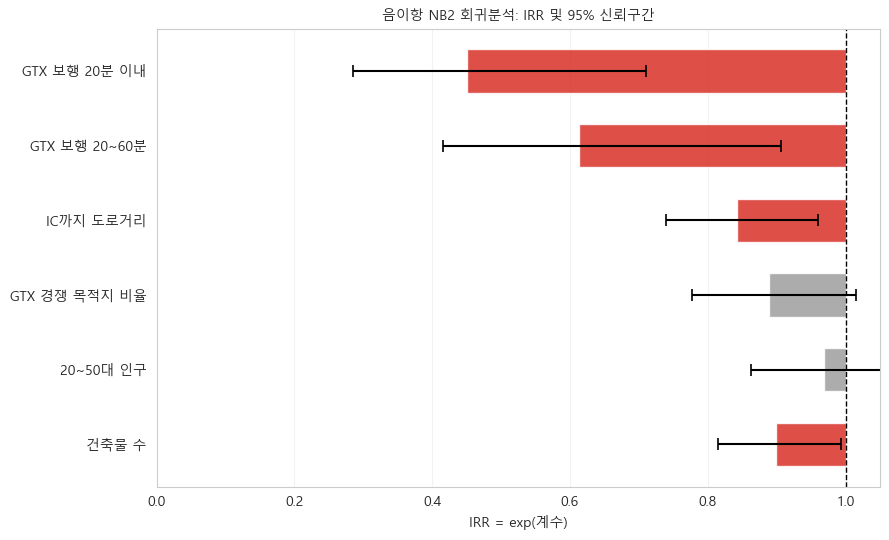

In [9]:
# 음이항 NB2 결과 시각화: IRR과 95% 신뢰구간만 표시
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = Path(r"C:\Windows\Fonts\malgun.ttf")
font_prop = fm.FontProperties(fname=str(font_path))
fm.fontManager.addfont(str(font_path))
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

LABELS = {
    'walk_20': 'GTX 보행 20분 이내',
    'walk_20_60': 'GTX 보행 20~60분',
    'ic_access': 'IC까지 도로거리',
    'competing_share': 'GTX 경쟁 목적지 비율',
    'pop_20_50': '20~50대 인구',
    'buildings': '건축물 수',
}

ci = nb_fit.conf_int().loc[X_FINAL]
irr_table = pd.DataFrame({
    '변수': [LABELS.get(v, v) for v in X_FINAL],
    'IRR': np.exp(nb_fit.params.loc[X_FINAL].values),
    'IRR 하한': np.exp(ci[0].values),
    'IRR 상한': np.exp(ci[1].values),
    'p-value': nb_fit.pvalues.loc[X_FINAL].values,
}).iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(irr_table))
x = irr_table['IRR'].to_numpy()
xerr = np.vstack([
    x - irr_table['IRR 하한'].to_numpy(),
    irr_table['IRR 상한'].to_numpy() - x,
])
colors = ['#d73027' if p < 0.05 else '#9e9e9e' for p in irr_table['p-value']]

ax.barh(y, x - 1, left=1, color=colors, alpha=0.85, height=0.58)
ax.errorbar(x, y, xerr=xerr, fmt='none', ecolor='black', capsize=4,
            elinewidth=1.5, capthick=1.2)
ax.axvline(1, color='black', linestyle='--', linewidth=1)
ax.set_xlim(0, 1.05)
ax.set_yticks(y)
ax.set_yticklabels(irr_table['변수'].tolist(), fontproperties=font_prop)
ax.set_xlabel('IRR = exp(계수)', fontproperties=font_prop)
ax.set_title('음이항 NB2 회귀분석: IRR 및 95% 신뢰구간', fontproperties=font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
ax.grid(axis='x', alpha=0.25)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()


## 포아송 모형과 음이항 모형의 우도비 검정

귀무가설은 alpha=0이며, 이 경우 음이항 모형이 포아송 모형으로 축약된다. alpha=0이 경계값이므로 혼합 카이제곱 분포를 사용한다.

In [10]:
from scipy.stats import chi2

# pois와 nb_fit은 동일 표본·변수·offset·노선 고정효과로 추정된 결과를 사용
lr_stat = 2 * (nb_fit.llf - pois.llf)
# alpha=0이 경계값이므로 0.5 * chi-square(1) p-value
lr_pvalue = 0.5 * chi2.sf(lr_stat, 1)

print(f'Poisson log-likelihood: {pois.llf:.4f}')
print(f'Negative Binomial log-likelihood: {nb_fit.llf:.4f}')
print(f'LR statistic: {lr_stat:.4f}')
print(f'LR Test of alpha=0 p-value: {lr_pvalue:.6g}')
print('결론:', 'alpha=0 기각 → 음이항 모형 지지' if lr_pvalue < 0.05 else 'alpha=0 기각 실패 → 포아송 모형과 차이 불충분')


Poisson log-likelihood: -1733.1043
Negative Binomial log-likelihood: -938.4253
LR statistic: 1589.3580
LR Test of alpha=0 p-value: 0
결론: alpha=0 기각 → 음이항 모형 지지


## 음이항 모형의 alpha 유의성 검정

alpha가 0보다 유의하게 큰지 확인한다.

In [11]:
alpha_name = 'alpha'
alpha_hat = float(nb_fit.params.iloc[-1] if hasattr(nb_fit.params, "iloc") else nb_fit.params[-1])
alpha_p = float(nb_fit.pvalues.iloc[-1] if hasattr(nb_fit.pvalues, "iloc") else nb_fit.pvalues[-1])
print(f'alpha coefficient: {alpha_hat:.4f}')
print(f'alpha coefficient p-value: {alpha_p:.6g}')
print('결론:', 'alpha가 0보다 유의하게 큼 → 과산포 확인' if alpha_p < 0.05 else 'alpha가 0보다 유의하지 않음 → 포아송 모형과 비교 필요')


alpha coefficient: 0.2193
alpha coefficient p-value: 3.04326e-09
결론: alpha가 0보다 유의하게 큼 → 과산포 확인


## 독립변수 상관관계 히트맵

음이항 회귀모형에 포함된 독립변수 사이의 상관관계를 확인한다.

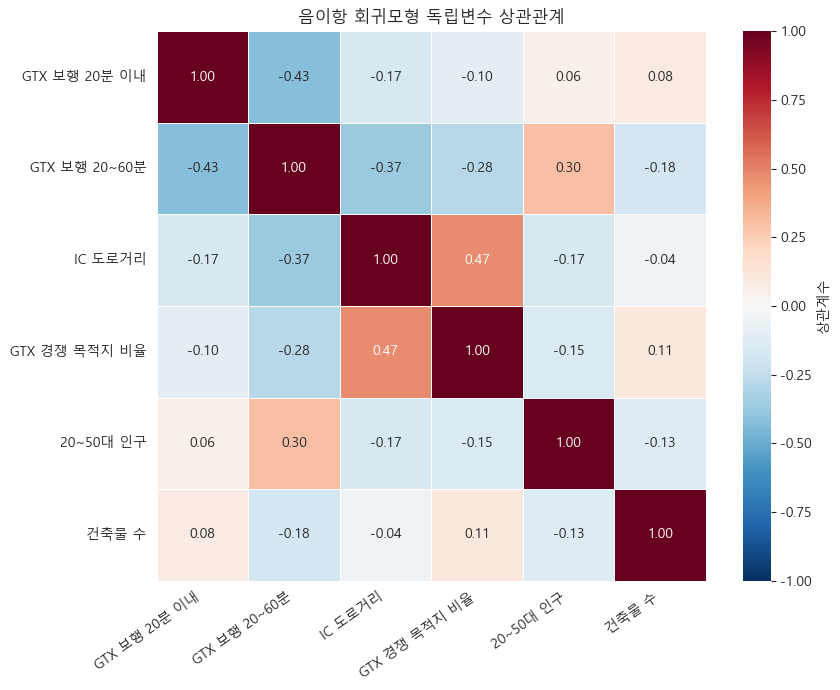

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

heatmap_labels = {
    'walk_20': 'GTX 보행 20분 이내',
    'walk_20_60': 'GTX 보행 20~60분',
    'ic_access': 'IC 도로거리',
    'competing_share': 'GTX 경쟁 목적지 비율',
    'pop_20_50': '20~50대 인구',
    'buildings': '건축물 수'
}

corr_cols = [v for v in X_FINAL if v in f.columns]
corr = f[corr_cols].apply(pd.to_numeric, errors='coerce').corr()
corr.index = [heatmap_labels.get(v, v) for v in corr.index]
corr.columns = [heatmap_labels.get(v, v) for v in corr.columns]

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={'label': '상관계수'}
)
plt.title('음이항 회귀모형 독립변수 상관관계')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()